### Probability and Distributions

#### Step 1: Probability Word Problems
1. Does the filling process follow a normal distribution?

To determine whether the filling process follows a normal distribution, we will:

- Create a histogram of the bottle fill amounts.
- Overlay a normal distribution curve using the sample mean and standard deviation.
- Verify whether the Empirical Rule approximately applies:
- About 68% of data within 1 standard deviation
- About 95% within 2 standard deviations
- About 99.7% within 3 standard deviations

If these conditions are approximately satisfied and the histogram appears bell-shaped, the filling process can be considered approximately normally distributed.

2. What are the probabilities of under-filling or over-filling?

The company has established the following rejection limits:
- Under-filled bottles: less than 11.7 oz
- Over-filled bottles: more than 12.2 oz

The z-score formula will be used:
    z = σx − μ​

Where:
- x = observed value
- μ = mean
- σ = standard deviation

The cumulative distribution function (CDF) will then be used to determine:
- Probability of under-filling:
    P(X<11.7)
- Probability of over-filling:
    P(X>12.2)

3. Is the current process below the maximum rejection percentage of 5%?
The total rejection percentage is calculated as:
    P(X<11.7)+P(X>12.2)

Decision criteria:
- If rejection percentage < 5% → Process meets expectations
- If rejection percentage > 5% → Process does not meet expectations

### Step 2: Data Analysis Setup

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Load & view dataset
df = pd.read_csv("bottle_fills.csv")

df.head()
df.describe()

,fill_amount
count,1000.000000
mean,12.027233
std,0.108352
min,11.611045
25%,11.958052
50%,12.028160
75%,12.091863
max,12.888700


In [3]:
print(df.columns)

Index(['timestamp', 'fill_amount'], dtype='object')


In [4]:
# Extract Fill Amount Data
# Replace with actual column name if needed
fills = df.iloc[:, 1]

mean_fill = fills.mean()
std_fill = fills.std()

print("Mean Fill:", mean_fill)
print("Standard Deviation:", std_fill)

Mean Fill: 12.02723333476538
Standard Deviation: 0.1083520719201837


### Step 3: Initial Visualization and Normality Check

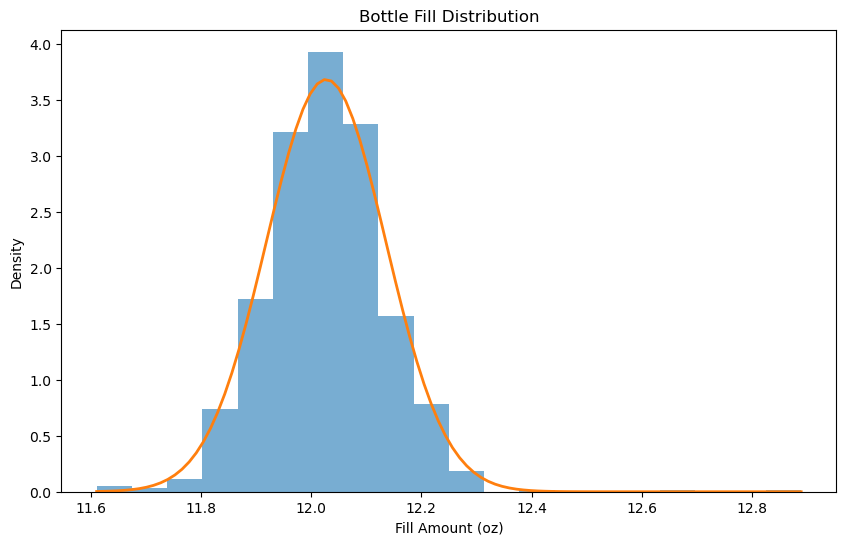

In [5]:
# Create Histogram with Normal Curve

plt.figure(figsize=(10,6))

# Histogram
count, bins, ignored = plt.hist(
    fills,
    bins=20,
    density=True,
    alpha=0.6
)

# Normal curve
x = np.linspace(min(fills), max(fills), 100)
pdf = norm.pdf(x, mean_fill, std_fill)

plt.plot(x, pdf, linewidth=2)

plt.title("Bottle Fill Distribution")
plt.xlabel("Fill Amount (oz)")
plt.ylabel("Density")

plt.show()

### Step 4: Empirical Rule Verification

In [6]:
within_1_std = np.mean(
    (fills >= mean_fill - std_fill) &
    (fills <= mean_fill + std_fill)
) * 100

within_2_std = np.mean(
    (fills >= mean_fill - 2*std_fill) &
    (fills <= mean_fill + 2*std_fill)
) * 100

within_3_std = np.mean(
    (fills >= mean_fill - 3*std_fill) &
    (fills <= mean_fill + 3*std_fill)
) * 100

print("Within 1 Standard Deviation:", within_1_std)
print("Within 2 Standard Deviations:", within_2_std)
print("Within 3 Standard Deviations:", within_3_std)

Within 1 Standard Deviation: 71.2
Within 2 Standard Deviations: 96.5
Within 3 Standard Deviations: 99.2


#### Interpretation

If the percentages are approximately:
- 68%
- 95%
- 99.7%

Then the data approximately follows a normal distribution.

### Step 5: Quality Control Analysis

In [7]:
# Define Control Limits
lower_limit = 11.7
upper_limit = 12.2

# Calculate Z-Scores
z_under = (lower_limit - mean_fill) / std_fill
z_over = (upper_limit - mean_fill) / std_fill

print("Z-score for Under-fill:", z_under)
print("Z-score for Over-fill:", z_over)

Z-score for Under-fill: -3.0200930076024197
Z-score for Over-fill: 1.5944934155194121


In [8]:
# Calculate Under-fill Probability
prob_under = norm.cdf(z_under)

print("Probability of Under-fill:", prob_under)

# Calculate Over-fill Probability
prob_over = 1 - norm.cdf(z_over)

print("Probability of Over-fill:", prob_over)

Probability of Under-fill: 0.0012634853686131246
Probability of Over-fill: 0.05541278217395029


In [9]:
# Calculate Total Rejection Percentage
rejection_probability = prob_under + prob_over
rejection_percentage = rejection_probability * 100

print("Total Rejection Percentage:", rejection_percentage)

# Percentage Within Acceptable Limits
acceptable_probability = 1 - rejection_probability

print("Percentage Within Acceptable Limits:",
      acceptable_probability * 100)


Total Rejection Percentage: 5.667626754256342
Percentage Within Acceptable Limits: 94.33237324574367


### Step 6: Final Recommendations

In [10]:
print("===== FINAL CONCLUSION =====")

if rejection_percentage < 5:
    print("The filling process meets the maximum rejection threshold of 5%.")
else:
    print("The filling process DOES NOT meet the maximum rejection threshold of 5%.")

if (
    65 <= within_1_std <= 71 and
    93 <= within_2_std <= 97 and
    98 <= within_3_std <= 100
):
    print("The filling data appears approximately normally distributed.")
else:
    print("The filling data may not perfectly follow a normal distribution.")

===== FINAL CONCLUSION =====
The filling process DOES NOT meet the maximum rejection threshold of 5%.
The filling data may not perfectly follow a normal distribution.


### Final Summary
#### Findings
- The bottle filling data was analyzed using descriptive statistics and visualization techniques.
- The Empirical Rule was used to assess whether the data followed a normal distribution.
- Probabilities of under-filling and over-filling were calculated using z-scores and the normal distribution.
- The total rejection percentage was compared against the company’s maximum acceptable rejection threshold of 5%.

#### Recommendation
Based on the calculated rejection percentage, the company can determine whether the current filling process is acceptable or whether process adjustments are needed to reduce waste and customer complaints.